In [1]:
# Install Dependencies

!pip install yfinance tensorflow scikit-learn joblib -q

In [2]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import math
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Download Stock Data

ticker = "AAPL"

# "AAPL"
# "TSLA"
# "NVDA"
# "MSFT"
# "GOOGL"

df = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01"
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600
2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400
2018-01-05,40.907566,40.994055,40.451740,40.542905,94640000
2018-01-08,40.755623,41.050156,40.657442,40.755623,82271200


In [4]:
# Dataset Information

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

df.info()

Dataset Shape: (1761, 5)

Columns:
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1761 entries, 2018-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1761 non-null   float64
 1   (High, AAPL)    1761 non-null   float64
 2   (Low, AAPL)     1761 non-null   float64
 3   (Open, AAPL)    1761 non-null   float64
 4   (Volume, AAPL)  1761 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB


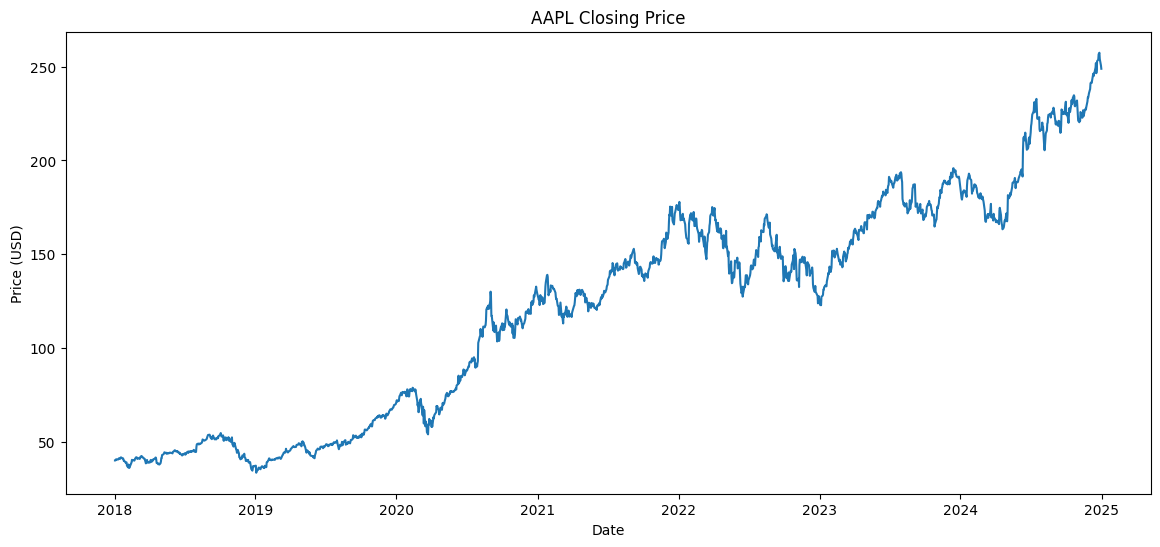

In [5]:
# Visualize Stock Price

plt.figure(figsize=(14,6))

plt.plot(
    df["Close"].squeeze()
)

plt.title(
    f"{ticker} Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.show()

In [6]:
# Extract Closing Price

data = df["Close"].squeeze()

print(type(data))
print(data.shape)

data.head()

<class 'pandas.core.series.Series'>
(1761,)


,AAPL
Date,
2018-01-02,40.267075
2018-01-03,40.260067
2018-01-04,40.447079
2018-01-05,40.907566
2018-01-08,40.755623


In [7]:
# Scale Data

scaler = MinMaxScaler(
    feature_range=(0,1)
)

scaled_data = scaler.fit_transform(
    data.values.reshape(-1,1)
)

print(scaled_data.shape)

(1761, 1)


In [8]:
# Create Sequences

sequence_length = 60

X = []
y = []

for i in range(
    sequence_length,
    len(scaled_data)
):

    X.append(
        scaled_data[
            i-sequence_length:i,
            0
        ]
    )

    y.append(
        scaled_data[
            i,
            0
        ]
    )

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1701, 60)
y Shape: (1701,)


In [9]:
# Reshape for LSTM

X = np.reshape(
    X,
    (
        X.shape[0],
        X.shape[1],
        1
    )
)

print("Reshaped X:", X.shape)

Reshaped X: (1701, 60, 1)


In [10]:
# Train Test Split

split_index = int(
    len(X) * 0.8
)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1360, 60, 1)
Test Shape: (341, 60, 1)


In [11]:
# Build LSTM Model

model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            1
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(
        units=50
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(25)
)

model.add(
    Dense(1)
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile Model

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [13]:
# Add Early Stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [14]:
# Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    ),
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0159 - mae: 0.0861 - val_loss: 9.1092e-04 - val_mae: 0.0251 - learning_rate: 0.0010
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0021 - mae: 0.0321 - val_loss: 8.8392e-04 - val_mae: 0.0246 - learning_rate: 0.0010
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017 - mae: 0.0289 - val_loss: 0.0012 - val_mae: 0.0287 - learning_rate: 0.0010
Epoch 4/30
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0019 - mae: 0.0304
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0018 - mae: 0.0301 - val_loss: 0.0012 - val_mae: 0.0279 - learning_rate: 0.0010
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0014 - mae: 0.0258 - val_loss: 0.0011 - val_mae: 0.0270 - learning_rate: 5.0000e-04
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0013 - mae: 0.0251 - val_loss: 0.0011 - val_mae: 0.0270 - learning_rate: 5.00

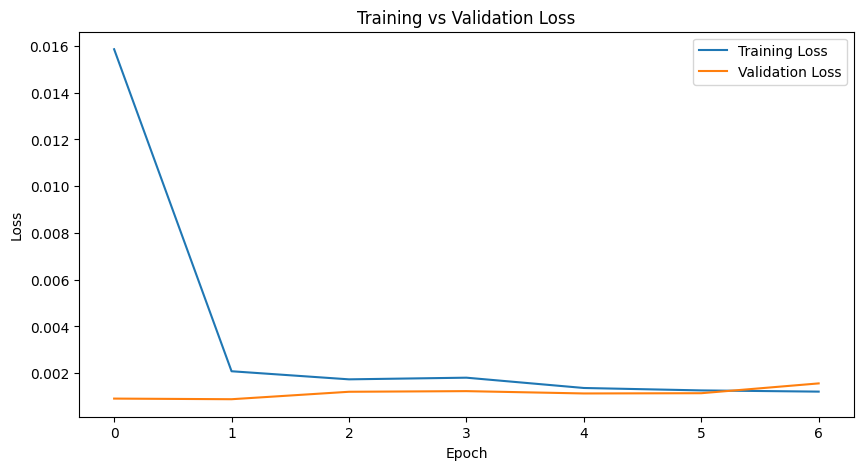

In [15]:
# Plot Training Loss

plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [16]:
# Make Predictions

predictions = model.predict(
    X_test
)

print(predictions.shape)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(341, 1)


In [17]:
# Convert Back to Original Prices

predictions = scaler.inverse_transform(
    predictions
)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [18]:
# Calculate RMSE

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predictions
    )
)

mape = np.mean(
    np.abs(
        (actual_prices - predictions)
        / actual_prices
    )
) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 6.65
MAPE: 2.77%


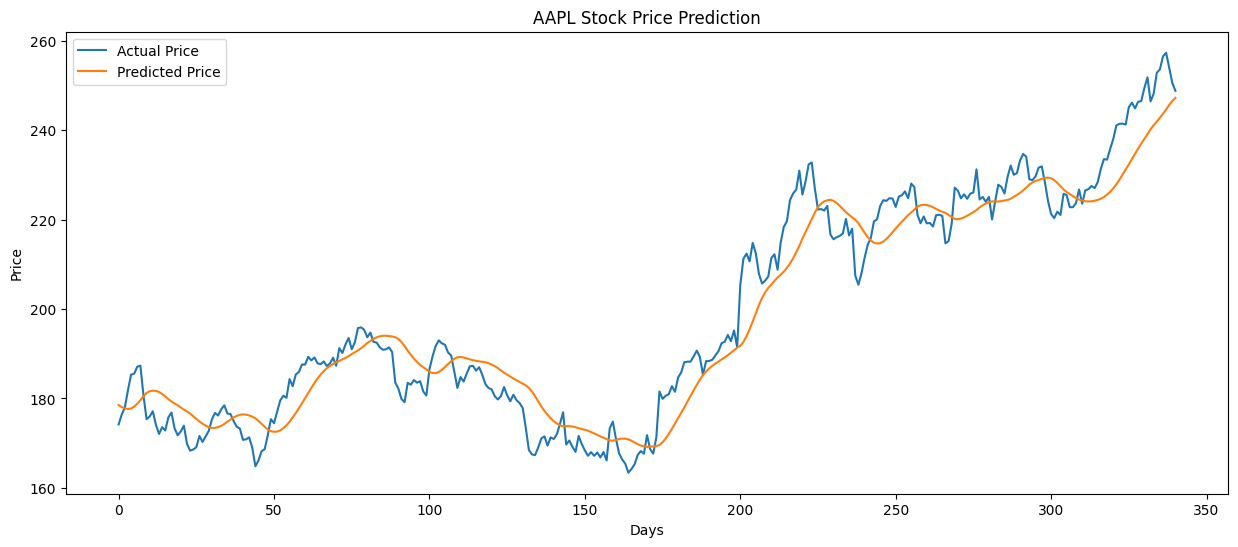

In [19]:
# Actual vs Predicted Graph

plt.figure(figsize=(15,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title(
    f"{ticker} Stock Price Prediction"
)

plt.xlabel("Days")

plt.ylabel("Price")

plt.legend()

plt.savefig(
    "actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [20]:
# Compare First 10 Predictions

comparison = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predictions.flatten()
})

comparison.head(10)

,Actual Price,Predicted Price
0,174.176361,178.493866
1,176.378479,178.059128
2,177.938766,177.760910
3,181.819641,177.623962
4,185.305588,177.743179
5,185.522827,178.163208
6,187.092941,178.790771
7,187.329941,179.599258
8,180.624771,180.514206
9,175.341599,181.234100


In [21]:
# Predict Next Day Price

last_60_days = scaled_data[-60:]

X_future = np.array(
    [last_60_days]
)

X_future = np.reshape(
    X_future,
    (
        X_future.shape[0],
        X_future.shape[1],
        1
    )
)

future_price = model.predict(
    X_future
)

future_price = scaler.inverse_transform(
    future_price
)

print(
    f"Predicted Next Day Closing Price: ${future_price[0][0]:.2f}"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Next Day Closing Price: $247.71


In [22]:
# Save Model

model.save(
    "stock_price_lstm_model.h5"
)

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
# Save Scaler

import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


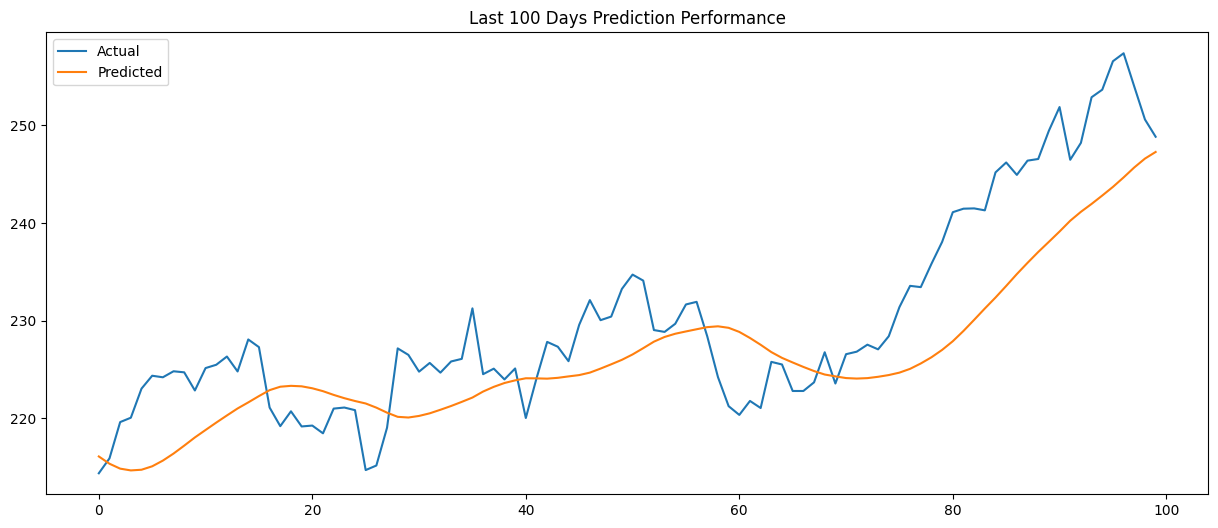

In [24]:
# Visualize Last 100 Predictions

plt.figure(figsize=(15,6))

plt.plot(
    actual_prices[-100:],
    label="Actual"
)

plt.plot(
    predictions[-100:],
    label="Predicted"
)

plt.title(
    "Last 100 Days Prediction Performance"
)

plt.legend()

plt.show()

In [25]:
# Model Summary

print("="*50)
print("STOCK PRICE PREDICTION USING LSTM")
print("="*50)
print(f"Stock Symbol: {ticker}")
print(f"Dataset Size: {len(data)}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(
    f"Predicted Next Day Price: ${future_price[0][0]:.2f}"
)
print("="*50)

STOCK PRICE PREDICTION USING LSTM
Stock Symbol: AAPL
Dataset Size: 1761
Training Samples: 1360
Testing Samples: 341
RMSE: 6.65
MAPE: 2.77%
Predicted Next Day Price: $247.71
